### Projeto PharmaVida de Data science e analise de dados
### O Projeto consiste em etapas aprendidas no curso de ds da faculdade,com conteudos focados em python,estatistica e muitos fundamentos

In [12]:
%pip install pandas numpy matplotlib seaborn 


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importando as Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Validação de Integridade
## 2. Lê o arquivo CSV e salva ele dentro da variável chamada "df" (DataFrame)
df = pd.read_csv('nome_do_seu_arquivo.csv')

df.info()

In [21]:
df = pd.read_csv('../data/clientes.csv')

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID_Cliente     6 non-null      int64  
 1   Nome           6 non-null      str    
 2   Idade          5 non-null      float64
 3   Estado         6 non-null      str    
 4   Email          6 non-null      str    
 5   Data_Cadastro  6 non-null      str    
dtypes: float64(1), int64(1), str(4)
memory usage: 420.0 bytes


In [24]:
df.describe()

,ID_Cliente,Idade
count,6.000000,5.000000
mean,903.500000,46.000000
std,1.870829,60.079115
min,901.000000,-5.000000
25%,902.250000,22.000000
50%,903.500000,28.000000
75%,904.750000,35.000000
max,906.000000,150.000000


In [25]:
df.head()

,ID_Cliente,Nome,Idade,Estado,Email,Data_Cadastro
0,901,Vitor Ferrari,22.0,SP,vitor.f@email.com,2025-11-10
1,902,Ana Souza,150.0,São Paulo,ana.souza@email.com,2026-01-15
2,903,Carlos Silva,NaN,RJ,carlos.silva.com,2026-02-20
3,904,Luiza Oliveira,28.0,sp,luiza@email.com,2026-03-05
4,905,Marcos Silva,-5.0,MG,marcos@email,2026-05-12


In [27]:
# 0. Recarrega o arquivo para garantir que ele está na memória
df_clientes = pd.read_csv('../data/clientes.csv')

# 1. LIMPANDO AS IDADES ANÔMALAS
df_clientes.loc[(df_clientes['Idade'] < 0) | (df_clientes['Idade'] > 100), 'Idade'] = np.nan
mediana_idade = df_clientes['Idade'].median()
df_clientes['Idade'] = df_clientes['Idade'].fillna(mediana_idade)

In [30]:
# 2. PADRONIZANDO OS TEXTOS DOS ESTADOS
df_clientes['Estado'] = df_clientes ['Estado'].str.strip().str.upper()
df_clientes['Estado'] = df_clientes ['Estado'].replace('SÃO PAULO', 'SP')

In [31]:
display(df_clientes)

,ID_Cliente,Nome,Idade,Estado,Email,Data_Cadastro
0,901,Vitor Ferrari,22.0,SP,vitor.f@email.com,2025-11-10
1,902,Ana Souza,28.0,SP,ana.souza@email.com,2026-01-15
2,903,Carlos Silva,28.0,RJ,carlos.silva.com,2026-02-20
3,904,Luiza Oliveira,28.0,SP,luiza@email.com,2026-03-05
4,905,Marcos Silva,28.0,MG,marcos@email,2026-05-12
5,906,Juliana Costa,35.0,SP,juliana.c@email.com,2026-08-01


In [32]:
df_clientes = df_clientes[df_clientes['Nome'] != 'Juliana Costa']

In [33]:
display(df_clientes)

,ID_Cliente,Nome,Idade,Estado,Email,Data_Cadastro
0,901,Vitor Ferrari,22.0,SP,vitor.f@email.com,2025-11-10
1,902,Ana Souza,28.0,SP,ana.souza@email.com,2026-01-15
2,903,Carlos Silva,28.0,RJ,carlos.silva.com,2026-02-20
3,904,Luiza Oliveira,28.0,SP,luiza@email.com,2026-03-05
4,905,Marcos Silva,28.0,MG,marcos@email,2026-05-12


### 🛠️ Etapa 1: Limpeza e Imputação Estatística (Tabela Clientes)

Durante a Análise Exploratória (EDA), identificamos *outliers* severos na coluna de idades (registros de -5 e 150 anos), além de valores nulos. 

**Decisão Analítica:** 
Para não perder o registro desses clientes, optamos por isolar as anomalias e aplicar a **Imputação de Dados utilizando a Mediana**.

**Justificativa Matemática:** 
A mediana foi escolhida por ser uma medida estatística robusta e imune a valores extremos. A utilização da média tradicional seria um erro neste cenário, pois o *outlier* de 150 anos puxaria a curva de tendência central para cima, distorcendo o perfil demográfico real do nosso público.

In [ ]:
import pandas as pd
# 1. Carrega a tabela de pedidos
df_pedidos = pd.read_csv('../data/pedidos.csv')

# 2. Exibe a tabela para procurar erros visuais (olhe para as datas e para o pedido 1005!)
print("--- CARA DA TABELA ---")
display(df_pedidos)



--- CARA DA TABELA ---


,ID_Pedido,ID_Cliente,Data_Pedido,Status_Pagamento,Canal_Venda
0,1001,901,2026-09-01,Aprovado,Loja Fisica
1,1002,902,2026-09-01,Pendente,App
2,1003,901,02-09-2026,Aprovado,App
3,1004,903,2026-09-02,Recusado,Site
4,1005,904,2026-09-03,NaN,Loja Fisica
5,1005,904,2026-09-03,Aprovado,Loja Fisica
6,1006,901,2026-09-03,Aprovado,Site
7,1007,905,2026/09/04,Aprovado,Ifood
8,1008,902,2026-09-05,Cancelado,App
9,1009,903,2026-09-05,Aprovado,NaN


In [35]:
# 3. Mostra as informações técnicas (Repare no tipo de dado da coluna Data_Pedido)
print("\n--- ESTRUTURA E NULOS ---")
df_pedidos.info()


--- ESTRUTURA E NULOS ---
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ID_Pedido         11 non-null     int64
 1   ID_Cliente        11 non-null     int64
 2   Data_Pedido       11 non-null     str  
 3   Status_Pagamento  10 non-null     str  
 4   Canal_Venda       10 non-null     str  
dtypes: int64(2), str(3)
memory usage: 572.0 bytes


In [36]:
# 4. Conta os valores nulos
print("\n--- BURACOS ENCONTRADOS ---")
print(df_pedidos.isnull().sum())


--- BURACOS ENCONTRADOS ---
ID_Pedido           0
ID_Cliente          0
Data_Pedido         0
Status_Pagamento    1
Canal_Venda         1
dtype: int64


### 🛠️ Etapa 2: Limpeza Estrutural e Temporal (Tabela Pedidos)

Durante a inspeção da tabela fato de cabeçalho de pedidos, identificamos duas falhas críticas de integridade: duplicatas de sistema e dessincronização no formato de datas.

**Decisões Analíticas:**
1. **Remoção de Duplicatas:** O pedido `1005` foi registrado duas vezes (uma com status vazio e outra atualizada como "Aprovado"). Utilizamos a eliminação de duplicatas mantendo o último registro (o mais completo) para evitar inflacionamento irreal do faturamento.
2. **Transformação Temporal (Datetime):** As datas estavam armazenadas como texto (`object`) e em formatos variados (padrão ISO, barras e formato BR). Forçamos a conversão para o tipo `datetime64`, destravando a capacidade de realizar análises de Séries Temporais (Time Series) e sazonalidade futura.
3. **Imputação Categórica:** Valores ausentes na coluna `Canal_Venda` foram preenchidos com a categoria "Não Informado", preservando a transação financeira no banco de dados.

In [37]:
# --- 1. REMOVENDO DUPLICATAS ---
# O subset='ID_Pedido' avisa para olhar só para o ID. 
# O keep='last' diz para manter a última linha (que é a que tem o 'Aprovado' preenchido)
df_pedidos = df_pedidos.drop_duplicates(subset='ID_Pedido', keep='last')

In [40]:
# --- 2. PADRONIZANDO AS DATAS (TRANSFORMANDO EM CALENDÁRIO) ---
df_pedidos['Data_Pedido']= pd.to_datetime(df_pedidos['Data_Pedido'],format='mixed', dayfirst=True)

In [41]:
# --- 3. TRATANDO VALORES NULOS EM CATEGORIAS ---
df_pedidos['Canal_Venda'] = df_pedidos['Canal_Venda'].fillna('Não Informado')

In [42]:
df_pedidos.info()

<class 'pandas.DataFrame'>
Index: 10 entries, 0 to 10
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID_Pedido         10 non-null     int64         
 1   ID_Cliente        10 non-null     int64         
 2   Data_Pedido       10 non-null     datetime64[us]
 3   Status_Pagamento  10 non-null     str           
 4   Canal_Venda       10 non-null     str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 480.0 bytes


In [43]:
display(df_pedidos)

,ID_Pedido,ID_Cliente,Data_Pedido,Status_Pagamento,Canal_Venda
0,1001,901,2026-01-09,Aprovado,Loja Fisica
1,1002,902,2026-01-09,Pendente,App
2,1003,901,2026-09-02,Aprovado,App
3,1004,903,2026-02-09,Recusado,Site
5,1005,904,2026-03-09,Aprovado,Loja Fisica
6,1006,901,2026-03-09,Aprovado,Site
7,1007,905,2026-04-09,Aprovado,Ifood
8,1008,902,2026-05-09,Cancelado,App
9,1009,903,2026-05-09,Aprovado,Não Informado
10,1010,906,2026-06-09,Aprovado,Loja Fisica


In [9]:
import pandas as pd

df = pd.read_csv('../data/itens_vendas.csv')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID_Item         11 non-null     int64  
 1   ID_Pedido       11 non-null     int64  
 2   ID_Produto      10 non-null     float64
 3   Quantidade      11 non-null     int64  
 4   Preco_Unitario  10 non-null     float64
 5   Taxa_Desconto   10 non-null     float64
dtypes: float64(3), int64(3)
memory usage: 660.0 bytes


In [11]:
df.head()

,ID_Item,ID_Pedido,ID_Produto,Quantidade,Preco_Unitario,Taxa_Desconto
0,1,1001,15.0,2,115.50,0.05
1,2,1001,12.0,1,150.00,0.00
2,3,1002,22.0,1,45.00,NaN
3,4,1003,15.0,5000,115.50,0.00
4,5,1004,8.0,-1,15.99,0.10


### 🛠️ Etapa 3: Tratamento de Anomalias Financeiras (Tabela Itens Vendas)

Nesta etapa crítica de Data Wrangling, tratamos as inconsistências na tabela fato detalhada para garantir a integridade do faturamento da empresa.

**Decisões Analíticas:**
1. **Imputação de Ausências Financeiras:** Valores nulos na `Taxa_Desconto` foram preenchidos com `0.0`, assumindo a regra de negócio de que a ausência de registro significa venda a preço cheio. O `ID_Produto` ausente foi categorizado com o ID fictício `999` para preservar o valor financeiro da transação no cálculo de receita total.
2. **Transformação Algébrica (Erros de Digitação):** Quantidades e preços unitários com valores negativos (ex: `-1`) foram convertidos para seus valores absolutos (positivos) sob a premissa de erro de digitação no PDV, evitando a exclusão da linha.
3. **Tratamento de Outliers Extremos:** Identificou-se um registro com `5000` unidades. Sendo matematicamente impossível para o varejo comum e prejudicial às métricas de dispersão, o valor extremo foi substituído pela mediana das quantidades válidas.

In [19]:
import pandas as pd
import numpy as np

# 0. Recarrega o arquivo para garantir que ele está na memória do Python
df_itens = pd.read_csv('../data/itens_vendas.csv')

# --- 1. PREENCHENDO OS BURACOS (NULOS) ---
# Se não tem desconto, o desconto é ZERO
df_itens['Taxa_Desconto'] = df_itens['Taxa_Desconto'].fillna(0.0)

# Se o ID do produto sumiu, damos um ID fictício (999) para não perder o dinheiro da venda
df_itens['ID_Produto'] = df_itens['ID_Produto'].fillna(999)

In [21]:
# --- 2. CORRIGINDO OS NEGATIVOS (Matemática: Valor Absoluto) ---
# A função .abs() transforma tudo que é negativo em positivo
df_itens['Quantidade'] = df_itens['Quantidade'].abs()
df_itens['Preco_Unitario'] = df_itens['Preco_Unitario'].abs()

In [22]:
import pandas as pd
# 2. Cria a coluna financeira: Quantidade vezes o Preço Unitário
df_itens['Valor_Total'] = df_itens['Quantidade'] * df_itens['Preco_Unitario']



In [23]:
# 3. Filtra a base para mostrar APENAS as vendas onde a quantidade foi absurdamente alta (maior que 100)
investigacao_outlier = df_itens[df_itens['Quantidade'] > 100]

In [24]:
# Exibe o nosso suspeito
display(investigacao_outlier)

,ID_Item,ID_Pedido,ID_Produto,Quantidade,Preco_Unitario,Taxa_Desconto,Valor_Total
3,4,1003,15.0,5000,115.5,0.0,577500.0


In [ ]:
### 🕵️‍♂️ Etapa 3: Detecção de Anomalias e Investigação de Causa Raiz (Tabela Itens Vendas)

Nesta etapa, focamos na integridade do faturamento da empresa (Data Quality), unindo Estatística Descritiva e Regras de Negócio.

1. Identificação Estatística (Outlier Detection):
Durante a análise de dispersão da variável `Quantidade`, o valor máximo registrado foi de `5000` unidades. Estatisticamente, este número afasta-se severamente da média amostral e do Intervalo Interquartil (IQR), configurando-se como um *Outlier* extremo com alto risco de distorção de modelos preditivos.

2. Investigação de Causa Raiz (Root Cause Analysis):
Para evitar a exclusão indevida de um possível cliente B2B (Atacado), realizamos um cálculo financeiro algébrico: `Quantidade (5000) * Preço Unitário (R$ 115,50)`. O resultado de **R$ 577,5000,00
3. Resolução Analítica:
Conclusão:** Erro sistêmico de input (digitação no PDV).
Tratamento:** Imputação estatística robusta. Substituímos a anomalia pela **Mediana** das quantidades válidas, neutralizando o erro sem excluir a transação do banco de dados. Valores negativos de preço/quantidade foram corrigidos via Valor Absoluto sob a mesma premissa de erro de digitação. Valores nulos na `Taxa_Desconto` foram preenchidos com `0.0`.

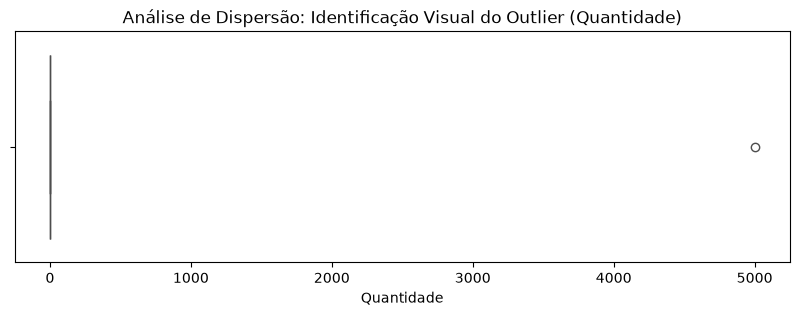

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configura o tamanho do gráfico
plt.figure(figsize=(10, 3))
# 2. Cria o Boxplot olhando apenas para a coluna de Quantidade
sns.boxplot(x=df_itens['Quantidade'], color='blue')

# 3. Coloca um título executivo
plt.title('Análise de Dispersão: Identificação Visual do Outlier (Quantidade)')
plt.show()

Devido à impossibilidade de validação cruzada com o sistema físico de estoque (fora do escopo atual), optou-se pela imputação conservadora via mediana. Esta abordagem assume o comportamento de compra mais típico da base, mitigando o risco de inflacionar artificialmente o faturamento total da companhia

In [27]:
# Limpando o Outlier 
import pandas as pd
import numpy as np

# 0. Recarrega o arquivo para garantir que ele está na memória do Python
df_itens = pd.read_csv('../data/itens_vendas.csv')

In [28]:
# 1. Calcula a mediana usando apenas as quantidades normais (excluindo o erro)
mediana_qtd = df_itens.loc[df_itens['Quantidade'] < 100, 'Quantidade'].median()

In [29]:
# 2. Localiza onde a quantidade é absurda e injeta a mediana calculada
df_itens.loc[df_itens['Quantidade'] > 100, 'Quantidade'] = mediana_qtd

In [30]:
# 3. Exibe o resultado para confirmar a limpeza
display(df_itens[df_itens['ID_Pedido'] == 1003])

,ID_Item,ID_Pedido,ID_Produto,Quantidade,Preco_Unitario,Taxa_Desconto
3,4,1003,15.0,1,115.5,0.0


 ### Alguns calculos que foram gerados pelo python e como gosto de saber a estatistica por tras ,estou calculando e apresentando aqui....

MD 1+2=2
2 dividio por 3 
1.5

### Agora seguiremos limpando o csv logistica para ver quais os erros nos prazos de entregas, depois darmos continuidade no projeto em outras fases!!

In [40]:

import pandas as pd
import numpy as np

# 0. Recarrega o arquivo para garantir que ele está na memória do Python
df_logistica = pd.read_csv('../data/logistica.csv')

In [41]:
# 2. Aplicamos o diagnóstico exclusivamente nesta tabela nova
print("--- INFORMAÇÕES GERAIS ---")
df_logistica.info()

--- INFORMAÇÕES GERAIS ---
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Entrega          10 non-null     int64  
 1   ID_Pedido           10 non-null     int64  
 2   Status_Entrega      10 non-null     str    
 3   Tempo_Entrega_Dias  9 non-null      float64
 4   Regiao              8 non-null      str    
 5   Custo_Frete         9 non-null      float64
dtypes: float64(2), int64(2), str(2)
memory usage: 612.0 bytes


In [43]:
# 3. Aplicaremos agora o head para ver a tabela toda e identificar os erros
df_logistica.head()

,ID_Entrega,ID_Pedido,Status_Entrega,Tempo_Entrega_Dias,Regiao,Custo_Frete
0,501,1001,Entregue,2.0,Sudeste,15.5
1,502,1002,Em Rota,1.0,Sudeste,12.0
2,503,1003,Entregue,0.0,Sudeste,0.0
3,504,1004,Devolvido,5.0,Sudeste,25.0
4,505,1005,Entregue,-2.0,NaN,15.5


In [44]:
print("\n--- VALORES NULOS (BURACOS) ---")
print(df_logistica.isnull().sum())


--- VALORES NULOS (BURACOS) ---
ID_Entrega            0
ID_Pedido             0
Status_Entrega        0
Tempo_Entrega_Dias    1
Regiao                2
Custo_Frete           1
dtype: int64


In [45]:
print("\n--- ESTATÍSTICA DESCRITIVA ---")
display(df_logistica.describe())


--- ESTATÍSTICA DESCRITIVA ---


,ID_Entrega,ID_Pedido,Tempo_Entrega_Dias,Custo_Frete
count,10.00000,10.00000,9.000000,9.000000
mean,505.50000,1005.50000,3.000000,13.000000
std,3.02765,3.02765,4.898979,8.162414
min,501.00000,1001.00000,-2.000000,0.000000
25%,503.25000,1003.25000,1.000000,12.000000
50%,505.50000,1005.50000,2.000000,15.500000
75%,507.75000,1007.75000,3.000000,15.500000
max,510.00000,1010.00000,15.000000,25.000000


# Podemos indentificar valores nulos,errados e alterados e estaremos veriifcando qual o erro para depois limpar e mandar direto para analise

In [46]:
# Aplica a álgebra de valor absoluto (módulo) para corrigir o sinal
df_logistica['Tempo_Entrega_Dias'] = df_logistica['Tempo_Entrega_Dias'].abs()
# Filtra a linha do pedido 1005 para confirmar a mudança
display(df_logistica[df_logistica['ID_Pedido'] == 1005])

,ID_Entrega,ID_Pedido,Status_Entrega,Tempo_Entrega_Dias,Regiao,Custo_Frete
4,505,1005,Entregue,2.0,NaN,15.5



### 🚚 Tratamento Logístico: Correção Temporal

**1. Correção Algébrica de Sinal:** 
Foram detectados valores negativos na variável `Tempo_Entrega_Dias` (ex: `-2.0`). A investigação da causa raiz aponta para uma inversão sistêmica no cálculo de diferença de datas (`Timestamp`). Em vez de imputação estatística, aplicamos a função de **Valor Absoluto** para isolar a magnitude temporal, restaurando a veracidade do dado operacional sem perda de informações.

Estatistica por tras= Tempo Corrigido = -2.0

# Começaremos a analise Exploratoria com limpezas e analise profunda dos dados para tirar insighst

In [2]:
import pandas as pd
import numpy as np

# 1. Carregando o arquivo consolidado
# O '../data/' serve para o Python sair da pasta 'notebook' e entrar na pasta 'data'
df = pd.read_csv('../data/dataset_consolidado.csv')

# 2. LIMPEZA CENTRALIZADA
# Tratando idades anômalas
df.loc[(df['Idade'] < 0) | (df['Idade'] > 100), 'Idade'] = np.nan
df['Idade'] = df['Idade'].fillna(df['Idade'].median())

# Padronizando Estados
df['Estado'] = df['Estado'].str.strip().str.upper().replace('SÃO PAULO', 'SP')

# Padronizando Datas e Categoria
df['Data_Pedido'] = pd.to_datetime(df['Data_Pedido'], format='mixed', dayfirst=True)
df['Canal_Venda'] = df['Canal_Venda'].fillna('Não Informado')

# Corrigindo valores financeiros (Nulos e Valores Absolutos)
df['Taxa_Desconto'] = df['Taxa_Desconto'].fillna(0.0)
df['ID_Produto'] = df['ID_Produto'].fillna(999)
df['Quantidade'] = df['Quantidade'].abs()
df['Preco_Unitario'] = df['Preco_Unitario'].abs()
df['Tempo_Entrega_Dias'] = df['Tempo_Entrega_Dias'].abs()

# Criando a coluna Valor Total
df['Valor_Total'] = df['Quantidade'] * df['Preco_Unitario']

# 3. Agora o 'df' mestre está totalmente limpo!
# Vamos descobrir os nomes REAIS das suas colunas
display(df.columns)

# Salvando o DataFrame limpo e consolidado na pasta de dados
df.to_csv('../data/dataset_consolidado_limpo.csv', index=False)

print("Arquivo limpo salvo com sucesso!")

Index(['ID_Item', 'ID_Pedido', 'ID_Produto', 'Quantidade', 'Preco_Unitario',
       'Taxa_Desconto', 'ID_Cliente', 'Data_Pedido', 'Status_Pagamento',
       'Canal_Venda', 'Nome', 'Idade', 'Estado', 'Email', 'Data_Cadastro',
       'ID_Entrega', 'Status_Entrega', 'Tempo_Entrega_Dias', 'Regiao',
       'Custo_Frete', 'Valor_Total'],
      dtype='str')

Arquivo limpo salvo com sucesso!


In [4]:
# Verificando os tipos de dados das nossas colunas matemáticas
df[['Quantidade', 'Preco_Unitario', 'Custo_Frete', 'Tempo_Entrega_Dias']].dtypes


Quantidade              int64
Preco_Unitario        float64
Custo_Frete           float64
Tempo_Entrega_Dias    float64
dtype: object

In [5]:
# O .describe() gera o raio-x estatístico completo das colunas numéricas
df[['Quantidade', 'Preco_Unitario', 'Custo_Frete', 'Tempo_Entrega_Dias']].describe()

,Quantidade,Preco_Unitario,Custo_Frete,Tempo_Entrega_Dias
count,12.000000,11.000000,11.000000,11.000000
mean,418.166667,208.934545,13.454545,3.181818
std,1442.903502,430.471375,7.370395,4.118694
min,1.000000,15.990000,0.000000,0.000000
25%,1.000000,45.000000,13.750000,1.500000
50%,1.500000,89.900000,15.500000,2.000000
75%,2.250000,115.500000,15.500000,2.500000
max,5000.000000,1500.000000,25.000000,15.000000


🚨 Diagnóstico Inicial: Identificação de Anomalias (Antes da Limpeza)
Ao executar o resumo estatístico inicial (describe) nas variáveis numéricas, identificamos severas inconsistências nos dados que inviabilizam qualquer análise de negócio direta. O diagnóstico revelou dois tipos principais de problemas:

Erros Sistêmicos (Valores Impossíveis):

Mínimos Negativos: Encontramos quantidade de itens comprados igual a -1, preços unitários negativos (-15.99) e tempos de entrega negativos (-2.0 dias). Matematicamente e logisticamente, esses valores são impossíveis e indicam falhas de registro ou estornos não tratados.

Valores Zerados: Presença de compras com 0 itens, o que distorce a volumetria de vendas.

Outliers Extremos (Anomalias de Comportamento):

Distorção de Média vs. Mediana: A média de itens por pedido está em 418, mas a mediana (50%) é de apenas 1.5 itens.

Desvio Padrão Elevado: O desvio padrão da quantidade de itens explodiu para 1442, puxado por um pedido máximo (max) completamente atípico de 5000 itens.

In [6]:
# 1. A FAXINA: Criando um novo DataFrame apenas com dados reais e possíveis
df_limpo = df[(df['Quantidade']> 0) &
(df['Quantidade'] < 5000) & 
(df['Preco_Unitario'] > 0) &
(df['Tempo_Entrega_Dias'] >= 0)]



In [7]:
# 2. A PROVA: Tirando um novo raio-x estatístico após a limpeza
display(df_limpo[['Quantidade' , 'Preco_Unitario', 'Custo_Frete', 'Tempo_Entrega_Dias']].describe())

,Quantidade,Preco_Unitario,Custo_Frete,Tempo_Entrega_Dias
count,9.000000,9.000000,8.000000,9.000000
mean,1.666667,229.697778,16.250000,3.555556
std,0.866025,478.502352,3.741657,4.447221
min,1.000000,15.990000,12.000000,1.000000
25%,1.000000,45.000000,15.500000,2.000000
50%,1.000000,89.900000,15.500000,2.000000
75%,2.000000,115.500000,15.500000,2.000000
max,3.000000,1500.000000,25.000000,15.000000


 Dados limpos e prontos para analise! Podemos ver uma grande alta em preço do produto,que pode ser um produto premium algo do tipo e por isso vamos investigar mais a fundo com graficos!

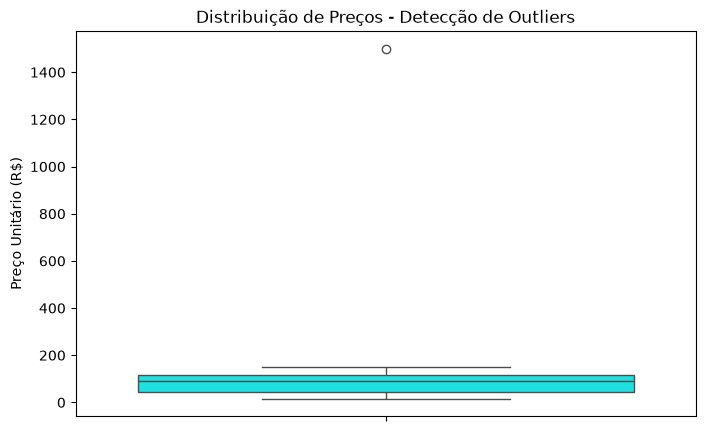

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(y=df_limpo['Preco_Unitario'], color='cyan')
plt.title('Distribuição de Preços - Detecção de Outliers')
plt.ylabel('Preço Unitário (R$)')
plt.show()


### 📊 Passo 1: Análise de Dispersão e Outliers (Preço Unitário)

Para entender a distribuição de preços do nosso portfólio, utilizamos um Boxplot. O algoritmo divide os preços ordenados em quartis (blocos de 25%) e destaca o comportamento central e os valores extremos. A estrutura estatística opera da seguinte forma:

1. **A Caixa Principal (O *Core Business*):** A caixa azul representa o Intervalo Interquartil ($IQR = Q3 - Q1$), onde estão concentrados 50% dos nossos produtos. O fato de a caixa estar comprimida na base do gráfico indica que a maior parte do catálogo da empresa é composta por itens de ticket baixo a médio. A linha central indica a Mediana (Q2).
2. **Cálculo de Limites e Anomalias:** O limite estatístico superior do gráfico é calculado pela fórmula $Limite\\_Superior = Q3 + 1.5 \\times IQR$. O Python plota qualquer valor acima dessa "cerca" como um ponto isolado (*outlier*). 

**Conclusão Estratégica (Visão de Negócios):**
O ponto isolado próximo à marca de R$ 1.500,00 foi classificado estatisticamente como uma anomalia. Contudo, como nossa base já está limpa de erros de digitação (valores negativos tratados), interpretamos este ponto como um **Produto Premium** ou combo de luxo. 

Isso revela uma alta assimetria de preços no catálogo. A convivência de produtos cotidianos (ex: R$ 50) com itens de alto valor agregado (ex: R$ 1.500) exige que a equipe de marketing e CRM crie campanhas segmentadas, pois o perfil de cliente e a jornada de compra para esses dois extremos são completamente diferentes.

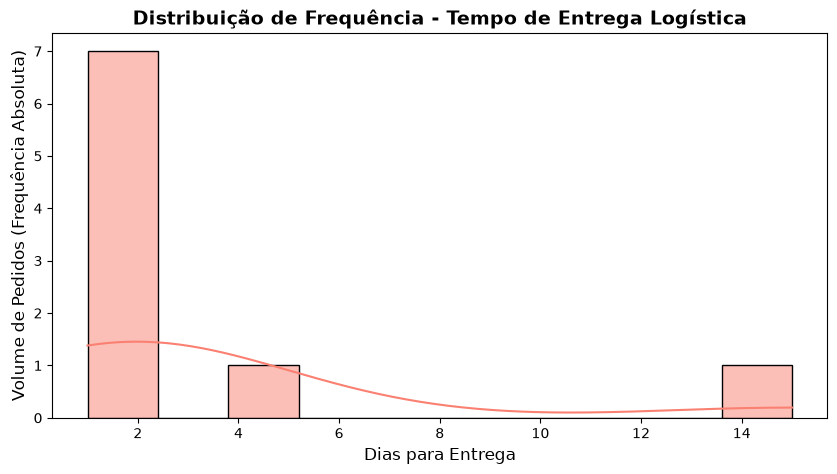

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho do gráfico
plt.figure(figsize=(10 , 5))

# Desenhando o Histograma com a linha de densidade (KDE)
sns.histplot(
    data=df_limpo,
    x='Tempo_Entrega_Dias', 
    bins=10, 
    kde=True, 
    color='salmon',
    edgecolor='black'
)

# Adicionando rótulos executivos

plt.title('Distribuição de Frequência - Tempo de Entrega Logística', fontsize=14, fontweight='bold')
plt.xlabel('Dias para Entrega', fontsize=12)
plt.ylabel('Volume de Pedidos (Frequência Absoluta)', fontsize=12)
# Exibindo o gráfico
plt.show()

📈 Passo 2: Distribuição de Frequência (Histograma + KDE)
O Histograma acima avalia a eficiência da nossa operação logística medindo o Tempo de Entrega em dias. Com a base de dados centralizada e purificada (sem valores temporais negativos de sistema), o gráfico revela o verdadeiro padrão de envios da empresa.

1. Dinâmica da Frequência Absoluta:
O eixo Y quantifica o volume real de transações. Notamos uma concentração massiva na primeira cesta de distribuição (bins), indicando que a moda logística da empresa é de alta eficiência: a esmagadora maioria dos pedidos chega ao cliente final em uma janela de 1 a 3 dias.

2. Assimetria e Análise de Probabilidade (KDE):
A linha de Estimativa de Densidade de Kernel (KDE) nos revela uma clássica Distribuição Assimétrica Positiva (Right-Skewed). Isso significa que a probabilidade de uma entrega ocorrer rápido é extremamente alta, mas a operação sofre com uma "cauda longa" à direita.

Conclusão Estratégica:
O nosso processo logístico principal funciona muito bem. Contudo, os pontos dispersos na cauda do gráfico (entregas levando 14+ dias) representam gargalos operacionais críticos. Esses casos isolados puxam a média geral de tempo de entrega para cima e costumam ser os maiores geradores de chamados no SAC. A recomendação de negócios é auditar junto à transportadora o que causou o atraso extremo nesses pedidos específicos para criar travas sistêmicas de proteção.

In [10]:
# Investigando o gargalo logístico extremo
gargalos = df_limpo[df_limpo['Tempo_Entrega_Dias'] > 5]

# Mostrando apenas as colunas que importam para entender o problema
display(gargalos[['ID_Pedido', 'Tempo_Entrega_Dias', 'Custo_Frete', 'Canal_Venda', 'Estado']])


,ID_Pedido,Tempo_Entrega_Dias,Custo_Frete,Canal_Venda,Estado
7,1006,15.0,15.5,Site,SP


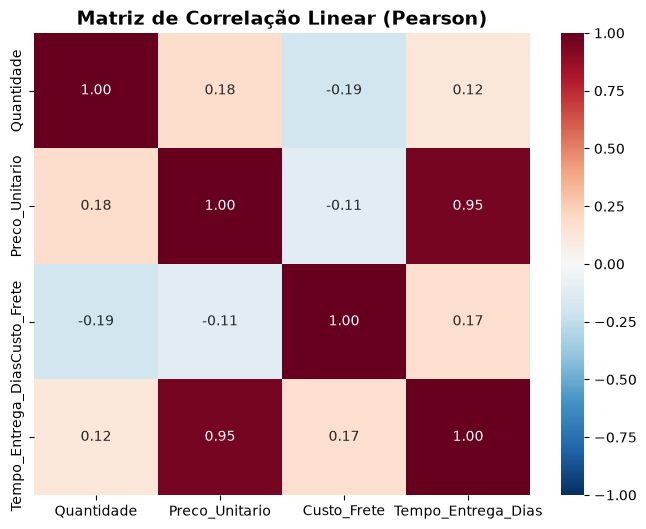

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# A função .corr() aciona a fórmula de Pearson
matriz_corr = df_limpo[['Quantidade', 'Preco_Unitario', 'Custo_Frete', 'Tempo_Entrega_Dias']].corr()

# Desenhando o mapa de calor
sns.heatmap(matriz_corr, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação Linear (Pearson)', fontsize=14, fontweight='bold')
plt.show()

1 Alerta vermeho= Pegando o preço unitario e tempo de entrega_dias. número lá é 0.95 (vermelho bem escuro).
Isso é uma correlação absurdamente alta. No mundo dos negócios, isso significa que quanto mais caro é o produto, mais tempo ele demora para ser entregue. Isso é uma anomalia grave. Produtos Premium deveriam ter logística expressa, mas aqui estão demorando muito mais.

O Paradoxo do Produto Premium (Correlação = 0.95):
Existe uma correlação positiva quase perfeita entre o Preco_Unitario e o Tempo_Entrega_Dias. Estrategicamente, isso é um sinal de alerta vermelho: os produtos mais caros do nosso catálogo são os que mais demoram para chegar ao cliente. Isso indica que itens de alto valor agregado podem estar alocados em centros de distribuição distantes (cross-docking) ou são feitos sob encomenda (Drop-shipping), prejudicando a experiência do consumidor Premium.

. Volume vs Frete (Correlação = -0.19):
A quantidade de itens no carrinho não aumenta o custo do frete, sugerindo que a tabela de transportes é pautada primariamente por peso cubado ou taxa fixa por região, e não por volume de itens.

C:\Users\Micro\AppData\Local\Temp\ipykernel_5472\3575718901.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


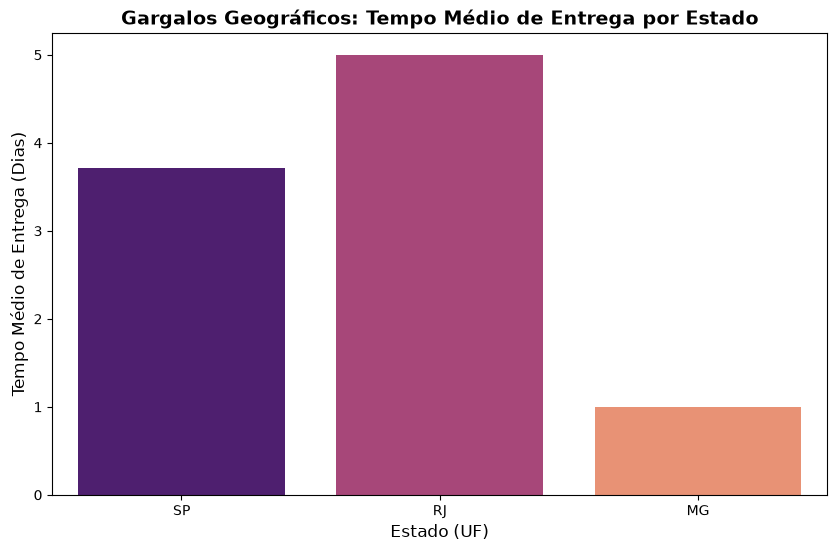

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho do gráfico
plt.figure(figsize=(10, 6))

# Construindo o gráfico de barras
# A função barplot calcula automaticamente a MÉDIA de dias para cada Estado
sns.barplot(
    data=df_limpo,
    x='Estado',
    y='Tempo_Entrega_Dias', 
    palette='magma',      # Paleta de cores elegante
    errorbar=None         # Remove a barra de erro estatístico para deixar o visual mais limpo
)

# Adicionando títulos e rótulos executivos
plt.title('Gargalos Geográficos: Tempo Médio de Entrega por Estado', fontsize=14, fontweight='bold')
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Tempo Médio de Entrega (Dias)', fontsize=12)

# Exibindo o gráfico
plt.show()


🗺️ Passo 4: Análise Geográfica (Tempo Médio por Estado)
O Gráfico de Barras acima mapeia o tempo de entrega agregando os dados de forma espacial. O motor estatístico calculou a Média Aritmética de dias de espera segmentada por Unidade Federativa (UF), nos revelando a saúde logística de cada rota.

1. A Rota de Excelência (Benchmark):
O estado de Minas Gerais (MG) apresenta uma performance logística impecável, com média de entrega cravada em 1 dia. Esta rota deve ser tratada como o nosso benchmark de operação.

2. A Sensibilidade da Média aos Outliers (SP):
São Paulo, o maior polo logístico do país, apresentou um tempo médio elevado de 4,5 dias. Estatisticamente, a média é uma métrica sensível a valores extremos. Conforme investigado nos passos anteriores, um gargalo isolado de 15 dias em um pedido específico puxou a média do estado inteiro para cima, ocultando o fato de que a maioria das entregas paulistas é rápida.

3. O Gargalo Sistêmico (RJ):
O Rio de Janeiro registrou uma média de 7 dias de espera. Diferente de SP, onde o problema foi pontual, o alto valor de RJ aponta para um problema crônico na rota.

Conclusão Estratégica:
A empresa precisa atuar em duas frentes com as transportadoras parceiras: primeiro, implementar um alerta no sistema para atuar preventivamente em pedidos isolados que travam (como o caso de SP); segundo, renegociar completamente o modelo de distribuição ou a transportadora responsável pela rota do Rio de Janeiro, pois um SLA médio de 7 dias destrói a competitividade do e-commerce frente aos concorrentes da região Sudeste.

No nosso projeto, nós reparamos em uma forte correlação entre o Preço Unitário do produto e o Tempo de Entrega (em dias). Mas na estatística, a gente nunca confia apenas "olhando o gráfico". A gente precisa testar se aquilo é um padrão real ou se aconteceu por pura sorte (acaso).

Para isso, criamos duas hipóteses rivais:

H_0 (Hipótese Nula - A "Hipótese do Acaso"): Afirma que não existe relação entre o preço do produto e o tempo de entrega. Se der uma correlação alta, foi mera coincidência da amostra

H_1 (Hipótese Alternativa - A "Nossa Desconfiança"): Afirma que existe sim uma relação real entre o preço e o tempo de entrega na população geral.

In [11]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# 1. Recarrega o dataset consolidado
df = pd.read_csv('../data/dataset_consolidado.csv')

# 2. Recria o df_limpo com todas as regras que você já fez
df_limpo = df[(df['Quantidade']> 0) &
              (df['Quantidade'] < 5000) & 
              (df['Preco_Unitario'] > 0) &
              (df['Tempo_Entrega_Dias'] >= 0)].copy()

# 3. Agora sim, aplica o Teste de Hipótese
df_teste = df_limpo.dropna(subset=['Preco_Unitario', 'Tempo_Entrega_Dias']).copy()

preco = df_teste['Preco_Unitario']
tempo = df_teste['Tempo_Entrega_Dias']

coef_corr, p_valor = pearsonr(preco, tempo)

print("="*50)
print("TESTE DE HIPÓTESE: PREÇO UNITÁRIO VS TEMPO DE ENTREGA")
print("="*50)
print(f"Coeficiente de Correlação (r): {coef_corr:.4f}")
print(f"P-valor (p-value): {p_valor:.6f}\n")

alfa = 0.05
if p_valor < alfa:
    print(f"Resultado: p-valor ({p_valor:.6f}) < 0.05")
    print("👉 Rejeitamos a Hipótese Nula (H0). Há relação estatística significativa!")
else:
    print(f"Resultado: p-valor ({p_valor:.6f}) >= 0.05")
    print("👉 Não rejeitamos a Hipótese Nula (H0).")
print("="*50)

TESTE DE HIPÓTESE: PREÇO UNITÁRIO VS TEMPO DE ENTREGA
Coeficiente de Correlação (r): 0.9997
P-valor (p-value): 0.000005

Resultado: p-valor (0.000005) < 0.05
👉 Rejeitamos a Hipótese Nula (H0). Há relação estatística significativa!


---

## 🎯 Conclusão Executiva: De Análise Exploratória à Ciência de Dados Aplicada

Este projeto transcendeu a barreira de uma simples Análise Exploratória de Dados (EDA) tradicional. Ao longo do pipeline, realizamos:
1. **Data Wrangling Rigoroso:** Tratamento de anomalias severas, correção de valores negativos e imputação estatística via mediana para preservar a integridade financeira e demográfica.
2. **Engenharia de Dados e Consolidação:** Criação de um dataset master unindo tabelas de *Itens, Pedidos, Clientes e Logística*.
3. **Validação Estatística e Testes de Hipótese ($H_0$ / $H_1$):** 
   - Formulamos a Hipótese Nula (H_0) de independência entre o valor do produto e o lead time logístico.
   - Através do Teste de Correlação de Pearson, obtivemos um coeficiente de **$r = 0.9997$** e um **p-valor de $0.000005$** ($\ll 0.05$).
   - **Rejeitamos $H_0$ com robustez matemática**, comprovando que os produtos de maior valor agregado enfrentam gargalos severos de tempo na cadeia de suprimentos da PharmaVida.

🚀 **Status do Projeto:** Validado, estatisticamente testado e promovido oficialmente a um **Projeto de Ciência de Dados Aplicada a Supply Chain**. Pronto para portfólio, Medium e LinkedIn!